In [1]:
# import packages and the shared BTMS_model solver

import os
import io
import time
import contextlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

import lib.BTMS_model as BTMS_model

# Reload the shared library so this notebook always uses the latest saved version.
BTMS_model = importlib.reload(BTMS_model)

# ------------------------------------------------------------
# Basic paths and result file names
# ------------------------------------------------------------

PROJECT_ROOT = os.getcwd()
DATA_INPUT_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'data_results')
os.makedirs(DATA_RESULTS_DIR, exist_ok=True)

CASE_ID = 'C0002'
REVISION = 'R00'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'VAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
RESULT_EXCEL_PATH = os.path.join(DATA_RESULTS_DIR, f'{RESULT_BASENAME}.xlsx')
RESULT_FIGURE_PATH = os.path.join(DATA_RESULTS_DIR, f'{RESULT_BASENAME}.png')
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'

print(f'BTMS_model loaded from: {BTMS_model.__file__}')
print(f'Result basename: {RESULT_BASENAME}')
print(f'Result Excel path: {RESULT_EXCEL_PATH}')
print(f'Result figure path: {RESULT_FIGURE_PATH}')


BTMS_model loaded from: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\lib\BTMS_model.py
Result basename: C0002R00_PARK25_LC_1D_VAL
Result Excel path: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0002R00_PARK25_LC_1D_VAL.xlsx
Result figure path: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0002R00_PARK25_LC_1D_VAL.png


In [2]:
# read Qbat(W) using the same time relation as C0003R00_PARK25_LC_1D_SCAN

SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                 # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the same downstream variable name as the parameter-scan notebook.
SIM_TIME_S = NUM_STEPS

HEAT_INPUT_FILE = os.path.join(
    DATA_INPUT_DIR,
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx'
)

heat_input_df = pd.read_excel(HEAT_INPUT_FILE, sheet_name='Sheet1')
power_generation_data_1s = heat_input_df['Qbat(W)'].dropna().to_numpy(dtype=float)

if len(power_generation_data_1s) == 0:
    raise ValueError('No valid Qbat(W) data were found in the heat-input file.')

# The source data are 1-s single-cell heat-generation values.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Heat-input file: {HEAT_INPUT_FILE}')
print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')
print(
    f'Q_cell range: min={np.min(power_generation_data):.6g} W, '
    f'max={np.max(power_generation_data):.6g} W, '
    f'mean={np.mean(power_generation_data):.6g} W'
)


Heat-input file: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data\MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx
Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920
Q_cell range: min=0.0201991 W, max=4.15314 W, mean=0.671994 W


In [3]:
# single validation-case settings
# The physical and numerical relations are kept consistent with
# C0003R00_PARK25_LC_1D_SCAN.

BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg, single-cell mass
    'cp_bat': 830.0,         # J/(kg K), single-cell specific heat
    'D_bat': 18e-3,          # m, cell diameter
    'H_bat': 65e-3,          # m, cell height
}

MODULE_LAYOUT = {
    'N_r': 20,               # cells/control volumes along the coolant-flow direction
    'N_c': 16,               # battery columns in the transverse direction
}

LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,     # Pa
    'D_channel': 4e-3,       # m, circular cooling-channel diameter
    'L_channel': 0.41423277, # m, effective channel length
    'plate_thickness': 0.012,# m, equivalent conduction thickness
    'k_plate': 202.4,        # W/(m K)
}

SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

# One validated baseline selected from the same variables used in the scan.
VALIDATION_CASE = {
    'm_dot': 0.0027758346,   # kg/s per channel; total flow divided by 22 channels
    'T_water': 25.0,         # degC
    'num_cell_seg': 16.0 / 22.0,  # equivalent transverse cells represented by one channel
}

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']

N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r
N_cells_physical = N_r * N_c

fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']
D_channel = LIQUID_SETTINGS['D_channel']
L_channel = LIQUID_SETTINGS['L_channel']
plate_thickness = LIQUID_SETTINGS['plate_thickness']
k_plate = LIQUID_SETTINGS['k_plate']

solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

m_dot = float(VALIDATION_CASE['m_dot'])
T_water = float(VALIDATION_CASE['T_water'])
num_cell_seg = float(VALIDATION_CASE['num_cell_seg'])

if num_cell_seg <= 0:
    raise ValueError('num_cell_seg must be positive.')

# The module has 16 battery columns in the transverse direction.
# With num_cell_seg = 16/22, the equivalent number of parallel channels is 22.
num_parallel_channel = N_c / num_cell_seg

print('Validation-case settings loaded.')
print(f'num_seg = {num_seg}')
print(f'Physical cells in full module = {N_cells_physical}')
print(f'm_dot = {m_dot:.7f} kg/s')
print(f'T_water = {T_water:.2f} degC')
print(f'num_cell_seg = {num_cell_seg:.6g}')
print(f'Equivalent parallel channels = {num_parallel_channel:.6g}')


Validation-case settings loaded.
num_seg = 20
Physical cells in full module = 320
m_dot = 0.0027758 kg/s
T_water = 25.00 degC
num_cell_seg = 0.727273
Equivalent parallel channels = 22


In [4]:
# calculate water properties, channel geometry, and heat-transfer coefficient
# using exactly the same relations as the liquid-cooling parameter scan

T_water_K = T_water + 273.15

mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
Pr_water = cp_water * mu_water / k_water

A_cool_cs = np.pi * D_channel ** 2 / 4.0
A_HT_seg = np.pi * D_channel * L_channel / num_seg

u_water = m_dot / (rho_water * A_cool_cs)
Re_water = rho_water * u_water * D_channel / mu_water
Nu_water = BTMS_model.liquid_nusselt_number(
    Re_water,
    Pr_water,
    heating=False
)
h_water = Nu_water * k_water / D_channel
R_plate = plate_thickness / k_plate
htc_global = 1.0 / (1.0 / h_water + R_plate)
htc_cool = np.ones(num_seg) * htc_global

print('Liquid-cooling properties calculated.')
print(f'rho_water = {rho_water:.4f} kg/m3')
print(f'cp_water = {cp_water:.4f} J/(kg K)')
print(f'mu_water = {mu_water:.6e} Pa s')
print(f'k_water = {k_water:.6f} W/(m K)')
print(f'Pr_water = {Pr_water:.4f}')
print(f'A_cool_cs = {A_cool_cs:.6e} m2')
print(f'A_HT_seg = {A_HT_seg:.6e} m2')
print(f'u_water = {u_water:.6f} m/s')
print(f'Re_water = {Re_water:.3f}')
print(f'Nu_water = {Nu_water:.3f}')
print(f'h_water = {h_water:.3f} W/(m2 K)')
print(f'htc_global = {htc_global:.3f} W/(m2 K)')


Liquid-cooling properties calculated.
rho_water = 997.0476 kg/m3
cp_water = 4181.3150 J/(kg K)
mu_water = 8.900225e-04 Pa s
k_water = 0.606516 W/(m K)
Pr_water = 6.1358
A_cool_cs = 1.256637e-05 m2
A_HT_seg = 2.602701e-04 m2
u_water = 0.221548 m/s
Re_water = 992.756
Nu_water = 4.360
h_water = 661.103 W/(m2 K)
htc_global = 636.167 W/(m2 K)


In [5]:
# solve the single validation case by calling BTMS_model

start_time = time.time()
progress_interval = 50

# Initial battery temperature follows the parameter-scan relationship:
# T_bat_init = T_water_in.
T_bat = np.ones(num_seg) * T_water
T_cool = np.ones(num_seg) * T_water

T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
T_bat_history[0, :] = T_bat
T_water_history[0, :] = T_cool

# These arrays store energy over each numerical step because
# BTMS_model.cal_energy_balance multiplies heat rates by dt.
Q_bat_history_J = np.zeros(SIM_TIME_S + 1)
Q_cool_history_J = np.zeros(SIM_TIME_S + 1)
Q_res_history_J = np.zeros(SIM_TIME_S + 1)

print(f'Total time steps to solve: {SIM_TIME_S}')
print(f'Progress interval: {progress_interval} step(s)')

for k in range(SIM_TIME_S):
    t = time_s[k]
    is_cool = True

    args = {
        'num_seg': num_seg,
        'num_seg_bat': num_seg,
        'dt': dt,
        'T_cool_pre': T_cool,
        'T_bat_pre': T_bat,
        'u_cool_in': u_water,
        'p_cool': p_water,
        'fluid_cool': fluid,
        'A_HT_seg': A_HT_seg,
        'A_cool_cs': A_cool_cs,
        'm_bat': m_bat,
        'cp_bat': cp_bat,
        'D_bat': D_bat,
        'T_cool_in': T_water,
        'T_cool_out': max(float(T_cool[-1]), T_water),
        'is_cool': is_cool,
        'htc_cool': htc_cool,
        'cp_cool': cp_water,
        'rho_cool': rho_water,
        'Q_gen': power_generation_data[k],
        'num_cell_seg': num_cell_seg,
        'debug': False,
    }

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            T_dist = BTMS_model.solve_coolant_temperature_distribution(
                args,
                tol=solver_tol,
                maxiter=solver_maxiter,
                debug=False
            )
    except Exception as exc:
        print('\nSolver failed in the validation case.')
        print(f'time step k = {k}')
        print(f't = {t:.1f} s')
        print(f'Q_gen = {power_generation_data[k]} W/cell')
        print(f'm_dot = {m_dot} kg/s')
        print(f'T_water = {T_water} degC')
        print(f'num_cell_seg = {num_cell_seg}')
        print(f'u_water = {u_water}')
        print(f'Re_water = {Re_water}')
        print(f'Nu_water = {Nu_water}')
        print(f'htc_global = {htc_global}')
        print(f'A_HT_seg = {A_HT_seg}')
        print(f'A_cool_cs = {A_cool_cs}')
        print(f'T_bat_min/max before solve = {np.min(T_bat)}, {np.max(T_bat)}')
        print(f'T_cool_min/max before solve = {np.min(T_cool)}, {np.max(T_cool)}')
        print(f'error = {repr(exc)}')
        raise

    if not np.all(np.isfinite(T_dist)):
        raise FloatingPointError(
            f'Non-finite T_dist returned at k={k}, t={t:.1f} s.'
        )

    T_cool = T_dist[:num_seg]
    T_bat = T_dist[num_seg:]

    Q_cool_HT, Q_cool_change, Q_bat = BTMS_model.cal_energy_balance(
        T_dist,
        args
    )

    Q_bat_history_J[k + 1] = np.sum(Q_bat)
    Q_cool_history_J[k + 1] = np.sum(Q_cool_HT)

    Q_gen_model_J = (
        power_generation_data[k]
        * num_cell_seg
        * num_seg
        * dt
    )
    Q_res_history_J[k + 1] = abs(
        Q_gen_model_J - np.sum(Q_bat) - np.sum(Q_cool_HT)
    )

    T_bat_history[k + 1, :] = T_bat
    T_water_history[k + 1, :] = T_cool

    step_number = k + 1
    if (
        step_number == 1
        or step_number % progress_interval == 0
        or step_number == SIM_TIME_S
    ):
        elapsed = time.time() - start_time
        print(
            f'Step {step_number}/{SIM_TIME_S}, '
            f't={time_s[step_number]:.0f} s, '
            f'Tmax={np.max(T_bat):.4f} degC, '
            f'Tmin={np.min(T_bat):.4f} degC, '
            f'elapsed={elapsed:.1f} s',
            flush=True
        )

elapsed_total = time.time() - start_time
print('Transient validation simulation finished.')
print(f'Elapsed wall time = {elapsed_total:.2f} s')
print(f'Maximum energy residual = {np.max(Q_res_history_J):.6e} J')


Total time steps to solve: 1920
Progress interval: 50 step(s)
Step 1/1920, t=1 s, Tmax=25.0672 degC, Tmin=25.0671 degC, elapsed=0.2 s
Step 50/1920, t=50 s, Tmax=26.9167 degC, Tmin=26.8418 degC, elapsed=1.3 s
Step 100/1920, t=100 s, Tmax=27.1845 degC, Tmin=27.0110 degC, elapsed=2.2 s
Step 150/1920, t=150 s, Tmax=27.4117 degC, Tmin=27.1522 degC, elapsed=3.0 s
Step 200/1920, t=200 s, Tmax=27.4544 degC, Tmin=27.1222 degC, elapsed=4.1 s
Step 250/1920, t=250 s, Tmax=27.2805 degC, Tmin=26.9025 degC, elapsed=5.3 s
Step 300/1920, t=300 s, Tmax=27.1428 degC, Tmin=26.7403 degC, elapsed=6.4 s
Step 350/1920, t=350 s, Tmax=27.0374 degC, Tmin=26.6240 degC, elapsed=7.4 s
Step 400/1920, t=400 s, Tmax=26.9588 degC, Tmin=26.5428 degC, elapsed=8.3 s
Step 450/1920, t=450 s, Tmax=26.9017 degC, Tmin=26.4876 degC, elapsed=9.2 s
Step 500/1920, t=500 s, Tmax=26.8610 degC, Tmin=26.4510 degC, elapsed=10.0 s
Step 550/1920, t=550 s, Tmax=26.8324 degC, Tmin=26.4275 degC, elapsed=10.9 s
Step 600/1920, t=600 s, Tmax=2

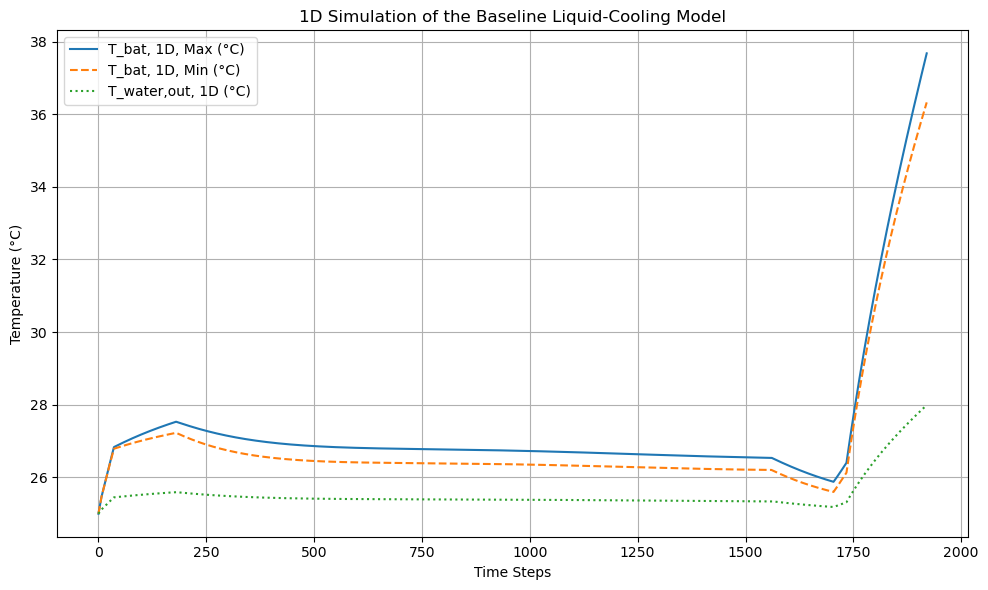

Tmax_mission = 37.6742 degC
Tmin_mission = 25.0000 degC
DeltaT_mission_max = 1.3499 degC
Twater_out_max = 27.9907 degC
Saved figure: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0002R00_PARK25_LC_1D_VAL.png


In [8]:
# calculate indicators and save the temperature figure

Tmax_1D = np.max(T_bat_history, axis=1)
Tmin_1D = np.min(T_bat_history, axis=1)
DeltaT_1D = Tmax_1D - Tmin_1D
Twater_out_1D = T_water_history[:, -1]

# Use the same plotting style as the reference BTMS T Solver notebook.
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.plot(time_s, Tmax_1D, label='T_bat, 1D, Max (°C)', linestyle='-')
plt.plot(time_s, Tmin_1D, label='T_bat, 1D, Min (°C)', linestyle='--')
plt.plot(time_s, Twater_out_1D, label='T_water,out, 1D (°C)', linestyle=':')

plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('1D Simulation of the Baseline Liquid-Cooling Model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    RESULT_FIGURE_PATH,
    dpi=600,
    bbox_inches='tight'
)
plt.show()

print(f'Tmax_mission = {np.max(Tmax_1D):.4f} degC')
print(f'Tmin_mission = {np.min(Tmin_1D):.4f} degC')
print(f'DeltaT_mission_max = {np.max(DeltaT_1D):.4f} degC')
print(f'Twater_out_max = {np.max(Twater_out_1D):.4f} degC')
print(f'Saved figure: {RESULT_FIGURE_PATH}')


In [7]:
# save the standardized validation result table

Q_cell_input_W = np.concatenate(([0.0], power_generation_data))
Q_model_path_input_W = Q_cell_input_W * num_cell_seg * num_seg
Q_module_input_W = Q_cell_input_W * N_cells_physical

# One modeled path represents num_seg * num_cell_seg cells.
# Multiplication by N_c / num_cell_seg gives the full 320-cell module equivalent.
Q_bat_module_equiv_J = Q_bat_history_J * num_parallel_channel
Q_cool_module_equiv_J = Q_cool_history_J * num_parallel_channel
Q_res_module_equiv_J = Q_res_history_J * num_parallel_channel

result_df = pd.DataFrame({
    'time_s': time_s,
    'Q_cell_W': Q_cell_input_W,
    'Q_model_path_W': Q_model_path_input_W,
    'Q_module_320cell_W': Q_module_input_W,
    'Tmax_1D_C': Tmax_1D,
    'Tmin_1D_C': Tmin_1D,
    'DeltaT_1D_C': DeltaT_1D,
    'Twater_out_1D_C': Twater_out_1D,
    'Q_bat_model_path_J': Q_bat_history_J,
    'Q_cool_model_path_J': Q_cool_history_J,
    'Q_residual_model_path_J': Q_res_history_J,
    'Q_bat_module_equiv_J': Q_bat_module_equiv_J,
    'Q_cool_module_equiv_J': Q_cool_module_equiv_J,
    'Q_residual_module_equiv_J': Q_res_module_equiv_J,
    'm_dot_kg_s': np.full(SIM_TIME_S + 1, m_dot),
    'T_water_in_C': np.full(SIM_TIME_S + 1, T_water),
    'num_cell_seg': np.full(SIM_TIME_S + 1, num_cell_seg),
})

result_df.to_excel(RESULT_EXCEL_PATH, index=False)

print(f'Saved standardized result Excel: {RESULT_EXCEL_PATH}')
print('Only one validation table file is generated for this case.')
result_df.head()


Saved standardized result Excel: d:\Users\liu\Desktop\论文初阶段\最新\eBATS_Liu\eBATS\data_results\C0002R00_PARK25_LC_1D_VAL.xlsx
Only one validation table file is generated for this case.


,time_s,Q_cell_W,Q_model_path_W,Q_module_320cell_W,Tmax_1D_C,Tmin_1D_C,DeltaT_1D_C,Twater_out_1D_C,Q_bat_model_path_J,Q_cool_model_path_J,Q_residual_model_path_J,Q_bat_module_equiv_J,Q_cool_module_equiv_J,Q_residual_module_equiv_J,m_dot_kg_s,T_water_in_C,num_cell_seg
0,0.0,0.000000,0.000000,0.000000,25.000000,25.000000,0.000000,25.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.002776,25.0,0.727273
1,1.0,2.689908,39.125942,860.770718,25.067227,25.067137,0.000090,25.016677,38.932376,0.193566,2.198242e-14,856.512274,4.258444,4.836131e-13,0.002776,25.0,0.727273
2,2.0,2.734463,39.774012,875.028270,25.135277,25.135007,0.000271,25.033549,39.384626,0.389386,1.014744e-13,866.461773,8.566497,2.232436e-12,0.002776,25.0,0.727273
3,3.0,2.772702,40.330210,887.264613,25.203990,25.203448,0.000542,25.050574,39.743214,0.586996,7.660539e-14,874.350699,12.913914,1.685319e-12,0.002776,25.0,0.727273
4,4.0,2.805486,40.807069,897.755518,25.273226,25.272322,0.000904,25.067719,40.021075,0.785994,5.773160e-15,880.463651,17.291867,1.270095e-13,0.002776,25.0,0.727273
